In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import patches

In [2]:
base_path = '../data/samples_evaluation/'

fig_save_path = '../figures/'

sample_dict = {
    'Samples = 5': '6lr7B_grafting_connector_candidates_temp07_s5_250831',
    'Samples = 10': '6lr7B_grafting_connector_candidates_temp07_s10_250901',
    'Samples = 30': '6lr7B_grafting_connector_candidates_temp07_s30_250901',
    'Samples = 50': '6lr7B_grafting_connector_candidates_temp07_s50_250901',
    'Samples = 80': '6lr7B_grafting_connector_candidates_temp07_s80_250901',
    'Samples = 100': '6lr7B_grafting_connector_candidates_temp07_s100_250831',
    'Samples = 500': '6lr7B_grafting_connector_candidates_temp07_s500_250901',
}

In [3]:
selected_stage = ['original', 'grafted', 'change']

selected_id = [
    '6lr7B_7nowA',
    '6lr7B_4dkaB',
    '6lr7B_8taoC',
    '6lr7B_3k1kC',
    '6lr7B_1zmyA',
]

affinity_dict = {
    'PDB_ID': [
        '6lr7B',
        '6lr7B_7nowA',
        '6lr7B_4dkaB',
        '6lr7B_8taoC',
        '6lr7B_3k1kC',
        '6lr7B_1zmyA',
    ],
    'Affinity': [
        31,
        35,
        69,
        76,
        120,
        150,
    ],
    'Yield':[
        1.3,
        8.4,
        9.8,
        1.4,
        0.5,
        3.5
    ]
    }

affinity_df = pd.DataFrame.from_dict(affinity_dict, orient='columns')

/tmp/ipykernel_532210/2601252819.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="PDB_ID", y="Yield", data=df_plot, palette=dict(zip(unique_ids, colors)))


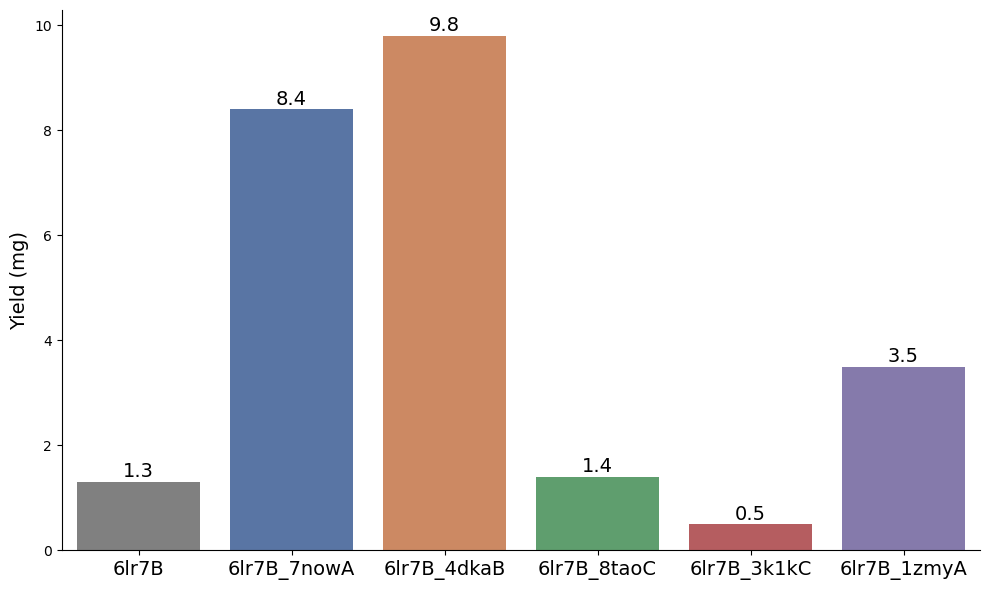

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 假设 affinity_df 已经存在，包含 "PDB_ID" 和 "Yield"
# affinity_df = pd.DataFrame.from_dict(affinity_dict, orient='columns')

# 保证只有需要的列
df_plot = affinity_df[['PDB_ID', 'Yield']].copy()

# 生成和 PDB_ID 数量一致的颜色
temp_color = ['#808080'] 
unique_ids = df_plot['PDB_ID'].unique()
n_sources = len(unique_ids) - 1 # Remove template
colors = sns.color_palette("deep", n_colors=n_sources)
colors = temp_color + colors
# source_color_map = {src: source_colors[i] for i, src in enumerate(sources)}

# cmap = plt.cm.get_cmap('Dark2')   # 可换 'Set3', 'Paired', 'tab10' 等
# colors = [cmap(i / n) for i in range(n)]

# 绘制柱状图
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="PDB_ID", y="Yield", data=df_plot, palette=dict(zip(unique_ids, colors)))

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.01,  # x, y 坐标
            '{:.1f}'.format(height),  # 显示3位小数
            ha="center", va="bottom", fontsize=14)  # 水平居中，底部对齐


# 美化
plt.xticks(rotation=0, ha='center', fontsize=14)
plt.ylabel("Yield (mg)", fontsize=14)
plt.xlabel(None)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

savepath='../figures/Lag16_yield_barplot.png'
plt.savefig(savepath, dpi=600)

plt.show()


## Plot ranks

In [5]:
def plot_pyramid_with_labels(
    df,
    pdb_col=0, value_col=1,
    percentages=[5,10,20,50,100],
    colors=None,
    figsize=(6,8),
    savepath=None,
    show_pdbs=None,       # list of PDBs to show/highlight (None => show all)
    show_only=False,      # if True show only show_pdbs
    highlight_color='black',
    highlight_linewidth=1.2,
    pyramid_width=2.0,
    pyramid_height=1.0,
    pyramid_center_x=0.0,
    pyramid_base_y=0.0,
    label_x=None,
    connector_pad=0.01,
    first_row_on_top=False,
    label_fontsize=9,      # 字体大小（points）
    max_columns=2,         # 1 or 2: 当 1 无法放下时可切到 2 列
    min_gap_factor=1.05    # 标签高度的放大系数，确保略有空隙
):
    """
    绘制分层金字塔并在右侧标注 PDB_ID，自动避免标签重叠并可分两列。
    连接线从金字塔右边缘上的“原始高度”（基于 df 顺序）画到标签位置（斜线）。
    """

    # --- 数据准备 ---
    pdbs_all = df.iloc[:, pdb_col].astype(str).values
    n = len(pdbs_all)
    if n == 0:
        raise ValueError("DataFrame is empty.")

    # show_pdbs 预处理（只保留存在的）
    if show_pdbs is not None:
        show_set = set(map(str, show_pdbs))
        present = [p for p in pdbs_all if p in show_set]
        missing = [p for p in show_set if p not in pdbs_all]
        if missing:
            print(f"Warning: these requested PDB_IDs were not found and will be ignored: {missing}")
    else:
        present = []

    # percentages 校验
    if percentages[-1] != 100:
        raise ValueError("Last element of percentages must be 100.")
    cum = np.array(percentages) / 100.0
    layer_fracs = np.diff(np.concatenate(([0.0], cum)))

    if colors is None:
        # colors = ["lightcoral", "lightsteelblue", "lightgreen", "khaki", "plum"]
        # colors = ["#B42B22",  "#830783", "#996121", "#0E8585", "#315A89"]   # Dark
        # colors = ["#FCB2AF", "#FFE2CE", "#C4D8E9", "#9BDFDF", "#BEBCDF"]  # Light
        colors = ["#D26546", "#EBBD76", "#986532", "#6EA486", "#3B5B8B"]
    if len(colors) < len(layer_fracs):
        colors = (colors * ((len(layer_fracs) // len(colors)) + 1))[:len(layer_fracs)]

    if label_x is None:
        label_x = pyramid_center_x + pyramid_width/2 + 0.18 * pyramid_width

    # --- 建图 ---
    fig, ax = plt.subplots(1,1, figsize=figsize)

    base_left = (pyramid_center_x - pyramid_width/2, pyramid_base_y)
    base_right = (pyramid_center_x + pyramid_width/2, pyramid_base_y)
    apex = (pyramid_center_x, pyramid_base_y + pyramid_height)

    def half_width_at_y(y):
        frac = (y - pyramid_base_y) / pyramid_height
        frac = np.clip(frac, 0.0, 1.0)
        return (pyramid_width / 2.0) * (1.0 - frac)

    # draw layers top -> bottom
    y_top = pyramid_base_y + pyramid_height
    for frac, col in zip(layer_fracs, colors):
        layer_h = frac * pyramid_height
        y_bottom = y_top - layer_h
        hw_top = half_width_at_y(y_top)
        hw_bottom = half_width_at_y(y_bottom)
        poly_pts = [
            (pyramid_center_x - hw_bottom, y_bottom),
            (pyramid_center_x - hw_top,    y_top),
            (pyramid_center_x + hw_top,    y_top),
            (pyramid_center_x + hw_bottom, y_bottom),
        ]
        patch = patches.Polygon(poly_pts, closed=True, facecolor=col, edgecolor="k", linewidth=0.6)
        ax.add_patch(patch)
        y_top = y_bottom
    # outline
    ax.add_patch(patches.Polygon([base_left, apex, base_right], closed=True, fill=False, edgecolor="k", linewidth=1.0))

    # --- 计算每行（每个 PDB）原始高度（中心） ---
    ys_norm = (np.arange(n) + 0.5) / n  # 0..1 bottom->top
    if first_row_on_top:
        ys_norm = 1.0 - ys_norm
    ys = pyramid_base_y + ys_norm * pyramid_height
    pdb_to_y = {p: y for p, y in zip(pdbs_all, ys)}

    # 决定要绘制哪些标签，以及哪些需要高亮
    if show_pdbs is None:
        labels_to_plot = pdbs_all.tolist()
        highlight_set = set()
    else:
        if show_only:
            labels_to_plot = present
            highlight_set = set(present)
        else:
            labels_to_plot = pdbs_all.tolist()
            highlight_set = set(present)

    # --- 估算单个标签在 data(纵)坐标系中的高度（依 label_fontsize） ---
    # 先画一次画布以获得 renderer 与 ax.bbox
    fig.canvas.draw()
    # 用一个临时文本来测量像素高度（取最长字符串的bbox来近似）
    sample_text = max(labels_to_plot, key=len) if labels_to_plot else "M"
    temp_text = ax.text(label_x, ys[0], sample_text, fontsize=label_fontsize, family='monospace', visible=False)
    renderer = fig.canvas.get_renderer()
    bbox = temp_text.get_window_extent(renderer=renderer)
    temp_text.remove()
    text_height_px = bbox.height
    axes_height_px = ax.bbox.height
    data_yrange = ax.get_ylim()[1] - ax.get_ylim()[0]
    dy_per_px = data_yrange / axes_height_px
    label_h_data = text_height_px * dy_per_px * min_gap_factor  # 加点余量
    min_gap = label_h_data

    # --- 布局：先贪心放置Y（单列），避免重叠（两次扫描） ---
    # 初始 desired positions in descending y (top -> bottom) for easier pushing down
    label_list = labels_to_plot.copy()
    # We'll operate in a column-wise manner later if needed
    desired = np.array([pdb_to_y[p] for p in label_list], dtype=float)

    # a function to perform two-pass greedy adjustment within bounds [ymin, ymax]
    def adjust_positions(desired_y, ymin, ymax, min_gap):
        # desired_y: array (len m) of desired positions (no particular order)
        # We will sort by desired_y descending, then push down if too close, then push up pass
        order = np.argsort(-desired_y)  # indices to visit from top to bottom
        y_adj = desired_y.copy()
        # first pass: top->bottom, ensure each is at most prev - min_gap
        for idx in order:
            if idx == order[0]:
                # ensure within bounds
                if y_adj[idx] > ymax:
                    y_adj[idx] = ymax
                continue
            # previous in top->bottom sequence:
            prev_idx = order[np.where(order == idx)[0][0] - 1]
            if y_adj[idx] > y_adj[prev_idx] - min_gap:
                y_adj[idx] = y_adj[prev_idx] - min_gap
        # second pass: bottom->top, ensure within bounds lower limit and push up if necessary
        order_b = order[::-1]  # bottom->top
        for idx in order_b:
            if idx == order_b[0]:
                if y_adj[idx] < ymin:
                    y_adj[idx] = ymin
                continue
            prev_idx = order_b[np.where(order_b == idx)[0][0] - 1]
            if y_adj[idx] < y_adj[prev_idx] + min_gap:
                y_adj[idx] = y_adj[prev_idx] + min_gap
        # final clamp to bounds and re-run small relaxation if clipped
        y_adj = np.clip(y_adj, ymin, ymax)
        # if some clipped and cause overlap, do another simple relaxation top->bottom
        for idx in order:
            if idx == order[0]:
                continue
            prev_idx = order[np.where(order == idx)[0][0] - 1]
            if y_adj[idx] > y_adj[prev_idx] - min_gap:
                y_adj[idx] = y_adj[prev_idx] - min_gap
        y_adj = np.clip(y_adj, ymin, ymax)
        return y_adj

    ymin = pyramid_base_y + 0.0 * pyramid_height
    ymax = pyramid_base_y + pyramid_height

    # try single-column first
    adjusted_single = adjust_positions(desired.copy(), ymin, ymax, min_gap)

    # check whether any overlaps still exist (distance < min_gap)
    def has_overlap(y_positions, min_gap):
        y_sorted = np.sort(y_positions)[::-1]
        diffs = y_sorted[:-1] - y_sorted[1:]
        return np.any(diffs < min_gap - 1e-9)

    need_two_columns = False
    if has_overlap(adjusted_single, min_gap):
        # if allowed, try splitting into two columns
        if max_columns >= 2:
            need_two_columns = True
        else:
            # try to relax by scaling min_gap down until fits (but not less than 0.7 * label_h_data)
            scale = 0.95
            adj = adjusted_single.copy()
            while has_overlap(adj, min_gap * scale) and scale > 0.7:
                adj = adjust_positions(desired.copy(), ymin, ymax, min_gap * scale)
                scale *= 0.95
            adjusted_single = adj
            if has_overlap(adjusted_single, min_gap * scale):
                # give up and keep adjusted_single (it will overlap a bit)
                pass

    if not need_two_columns:
        final_positions = adjusted_single
        columns = 1
        col_assignment = np.zeros(len(label_list), dtype=int)
    else:
        # split labels into two groups by alternating after sorting by desired (descending)
        order_desc = np.argsort(-desired)
        col_assignment = np.zeros(len(label_list), dtype=int)
        # Alternate assignment to try to balance vertical packing
        col_assignment[order_desc[0::2]] = 0
        col_assignment[order_desc[1::2]] = 1
        final_positions = np.zeros(len(label_list), dtype=float)
        # compute column bounds for label y (both columns share same ymin,ymax)
        # adjust each column separately
        for col in [0,1]:
            idxs = np.where(col_assignment == col)[0]
            if len(idxs) == 0:
                continue
            desired_col = desired[idxs]
            adj_col = adjust_positions(desired_col, ymin, ymax, min_gap)
            final_positions[idxs] = adj_col
        columns = 2

    # --- 绘制连接线与文字（连接点使用原始高度上的三角边界，线可斜） ---
    for i, pdb in enumerate(label_list):
        y_orig = pdb_to_y[pdb]
        y_label = final_positions[i]
        hw = half_width_at_y(y_orig)
        x_edge = pyramid_center_x + hw
        x_start = x_edge + np.sign(label_x - x_edge) * connector_pad * pyramid_width
        # for two columns, set label x to further right for column 1
        if columns == 1:
            x_text = label_x
        else:
            # column 0 near label_x, column1 further right
            if col_assignment[i] == 0:
                x_text = label_x
            else:
                x_text = label_x + 0.18 * pyramid_width

        is_high = (pdb in highlight_set)
        if is_high:
            lw = highlight_linewidth
            color = highlight_color
            alpha = 1.0
            ls = '-'
        else:
            lw = 0.6
            color = 'gray'
            alpha = 0.7
            ls = '--'

        # draw straight line from (x_start, y_orig) to (x_text - small offset, y_label)
        x_text_anchor = x_text - 0.01 * pyramid_width
        ax.plot([x_start, x_text_anchor], [y_orig, y_label], linewidth=lw, linestyle=ls, color=color, alpha=alpha)
        ax.text(x_text, y_label, pdb, va='center', ha='left', fontsize=label_fontsize, family='monospace',
                color=color, alpha=alpha)

    # formatting & legend (same as earlier)
    padding_left = pyramid_center_x - pyramid_width/2 - 0.2 * pyramid_width
    padding_right = label_x + 0.45 * pyramid_width
    ax.set_xlim(padding_left, padding_right)
    ax.set_ylim(pyramid_base_y - 0.02 * pyramid_height, pyramid_base_y + pyramid_height + 0.02 * pyramid_height)
    ax.axis('off')
    ax.set_aspect('equal', adjustable='box')

    cum_labels = []
    start = 0
    for p in percentages:
        cum_labels.append(f"{start}% → {p}%")
        start = p
    legend_x = pyramid_center_x - pyramid_width/2 - 0.02 * pyramid_width
    for i, lab in enumerate(cum_labels):
        y_legend = pyramid_base_y + pyramid_height - 0.06 * pyramid_height - i * 0.055 * pyramid_height
        ax.text(legend_x - 0.02 * pyramid_width, y_legend, lab, fontsize=14, va='center', ha='right',
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6))
        ax.add_patch(patches.Rectangle((legend_x, y_legend - 0.02 * pyramid_height),
                                      0.05 * pyramid_width, 0.035 * pyramid_height,
                                      facecolor=colors[i], edgecolor='k', linewidth=0.4))

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=600, bbox_inches='tight')
    plt.show()
    return fig, ax

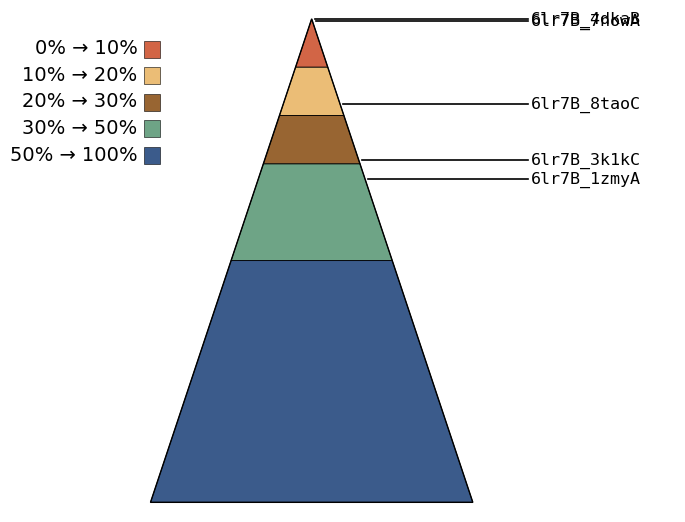

In [23]:

ori_score_df = pd.read_csv("../data/6lr7B_grafting_connector_all_temp07_s50_250904/extract_distance/full_avge/original_raw_embeddings.tsv", sep="\t")
selected_df = ori_score_df[['PDB_ID', 'original_euclidean_all_raw_embeddings']]

fig, ax = plot_pyramid_with_labels(
        selected_df,
        pdb_col=0,
        value_col=1,
        percentages=[10,20,30,50,100],
        pyramid_width=2.0,
        pyramid_height=3.0,
        pyramid_center_x=-0.1,
        pyramid_base_y=0.0,
        figsize=(7,10),
        show_pdbs=selected_id,
        show_only=True,
        first_row_on_top=True,
        label_fontsize=12,
        max_columns=3,
        savepath='/home/dhuang/work/Ig-fold/nanobody_db/final_version/figures/Lag16_pyramid.png'
    )

## Actual yield and pI

In [21]:
actual_yield_df = affinity_df[['PDB_ID', 'Yield']]

pred_hydropho_charge = pd.read_csv('../data/6lr7B_grafting_connector_all_temp07_s50_250904/properties/6lr7B_all_hydrophobicity_charge_pi.tsv', sep='\t')
pred_hydropho_charge = pred_hydropho_charge[['ID', 'PI']]
pred_hydropho_charge.loc[pred_hydropho_charge['ID'] == '6lr7B_6lr7B', 'ID'] = '6lr7B'


pred_hydropho_charge.rename(columns={'ID': 'PDB_ID'}, inplace=True)
pred_hydropho_charge.rename(columns={'PI': 'Isoelectric point'}, inplace=True)

merged_yield_df = pred_hydropho_charge.merge(actual_yield_df, how='inner', on='PDB_ID')

# Average

In [7]:
def extract_avge_affinity(table_path, selected_stage, selected_id, affinity_df):
    selected_embe = 'raw_embeddings'
    merged_df = None
    for stage in selected_stage:
        table_name = os.path.join(table_path, 'extract_distance/', 'filter_avge', f'{stage}_{selected_embe}.tsv')
        df = pd.read_csv(table_name, sep='\t').iloc[:, :2]
        
        if merged_df is None:
            merged_df = df.copy()
        else:
            merged_df = merged_df.merge(df, how='inner', on='PDB_ID')

    filtered_df = merged_df[merged_df['PDB_ID'].isin(selected_id)].copy()

    affinity_filtered_df = affinity_df.merge(filtered_df, how='inner', on='PDB_ID')

    return affinity_filtered_df

def plot_affinity(affinity_filtered_df):
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt
    from scipy.stats import pearsonr
    from scipy.stats import spearmanr

    x = affinity_filtered_df['grafted_euclidean_all_raw_embeddings']
    y = affinity_filtered_df['Affinity']
    pdb_ids = affinity_filtered_df['PDB_ID']

    # Pearson r、p-value and R²
    r, p_val = pearsonr(x, y)
    r2 = r**2

    # Plot
    sns.set(style="white")
    fig, ax = plt.subplots(figsize=(8,6))

    # Scatter
    sns.scatterplot(x=x, y=y, s=50, alpha=0.7, ax=ax)

    # Regression line
    sns.regplot(
        x=x, y=y,
        scatter=False,
        ci=95,
        line_kws={'color':'red','lw':1.5},
        ax=ax,
        n_boot=1000, seed=42
    )

    # Refference line
    ax.axhline(31, color='blue',  linestyle='--', lw=1, label='Lag16 = 31 nM')

    # Name for each point
    for i in range(len(x)):
        ax.annotate(
            pdb_ids.iloc[i],
            (x.iloc[i], y.iloc[i]),
            textcoords="offset points",  # Shift text
            xytext=(4, 6),
            ha='left',
            fontsize=8,
            color='gray',
            alpha=0.8
        )

    title_str = f"$r={r:.2f},\\ \\;R^2={r2:.2f},\\ \\;p={p_val:.2g}$"
    ax.set_title(title_str, loc='center', fontsize=12, pad=10, fontstyle='italic')

    ax.set_xlabel('Connector embeddings similarity', fontsize=14)
    ax.set_ylabel('Affinity', fontsize=14)

    ax.legend(loc='upper left', fontsize=12)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()


Samples = 5 6lr7B_grafting_connector_candidates_temp07_s5_250831


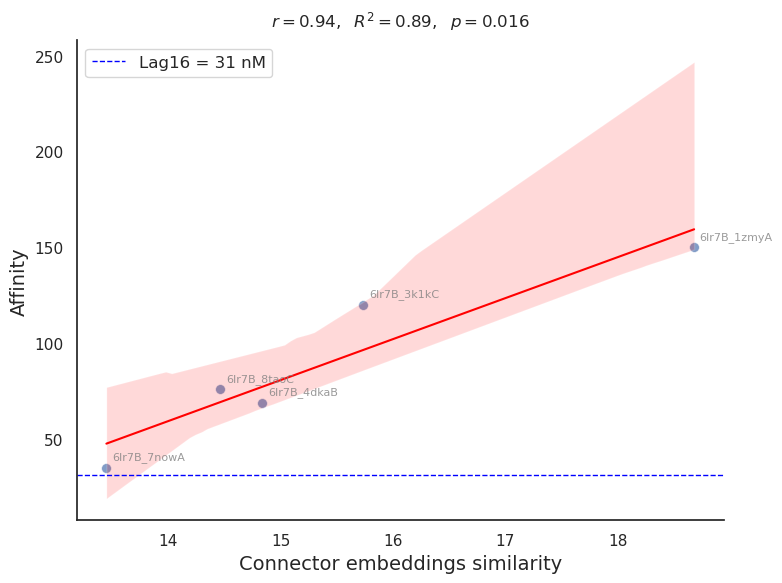

Samples = 10 6lr7B_grafting_connector_candidates_temp07_s10_250901


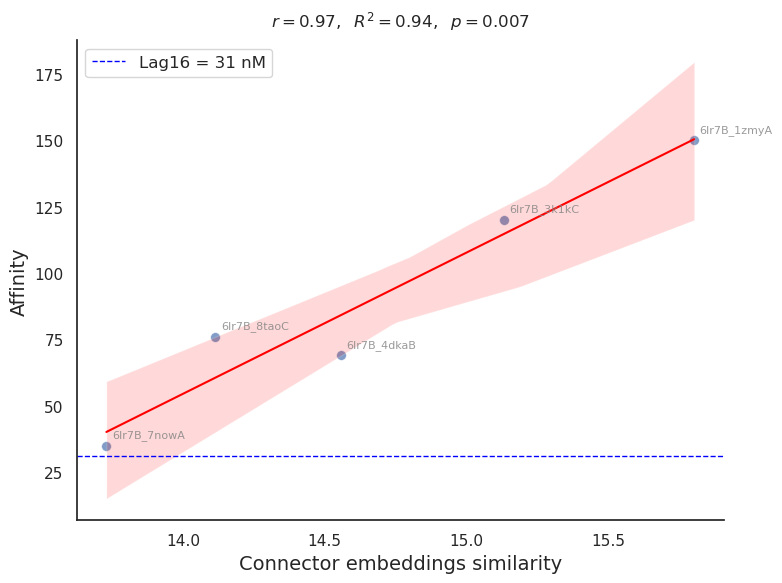

Samples = 30 6lr7B_grafting_connector_candidates_temp07_s30_250901


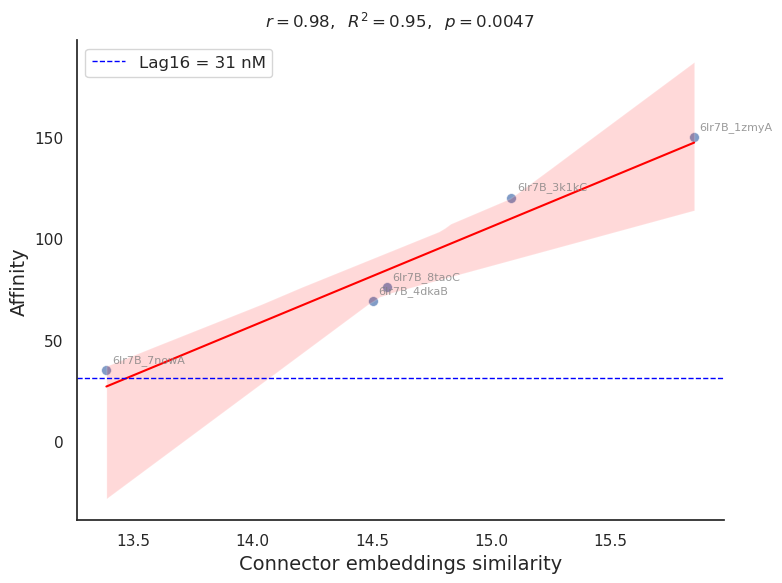

Samples = 50 6lr7B_grafting_connector_candidates_temp07_s50_250901


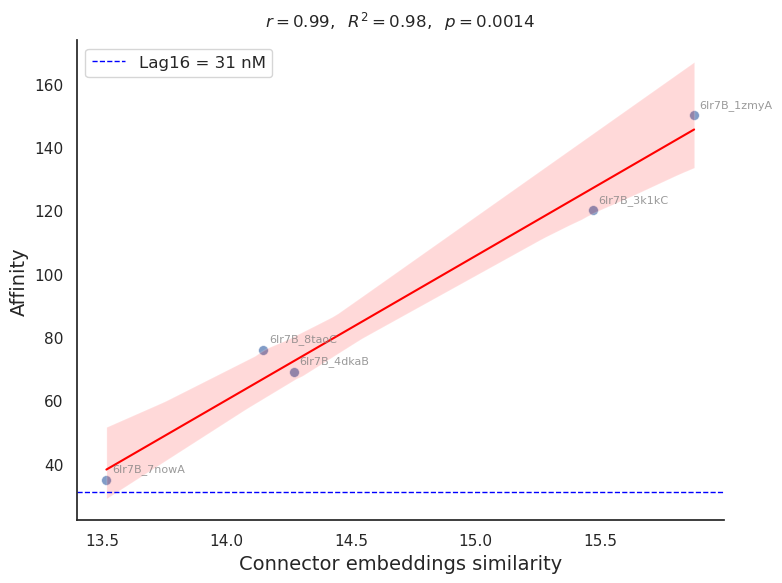

Samples = 80 6lr7B_grafting_connector_candidates_temp07_s80_250901


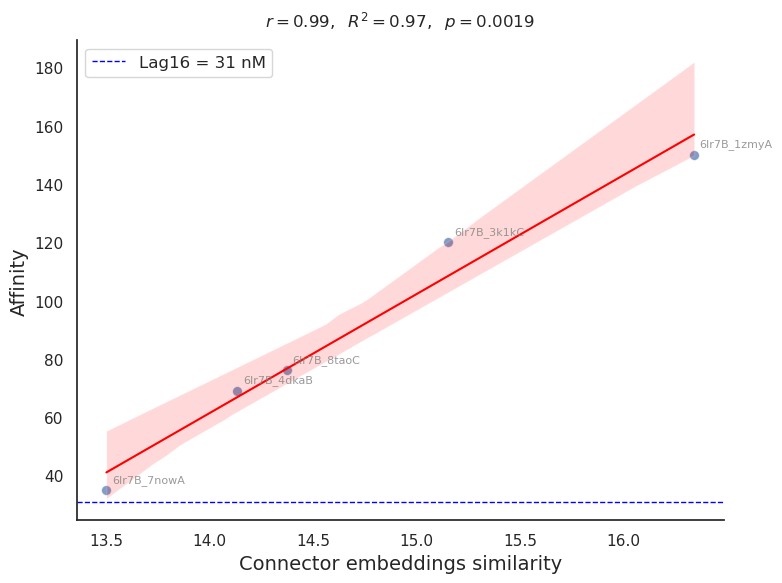

Samples = 100 6lr7B_grafting_connector_candidates_temp07_s100_250831


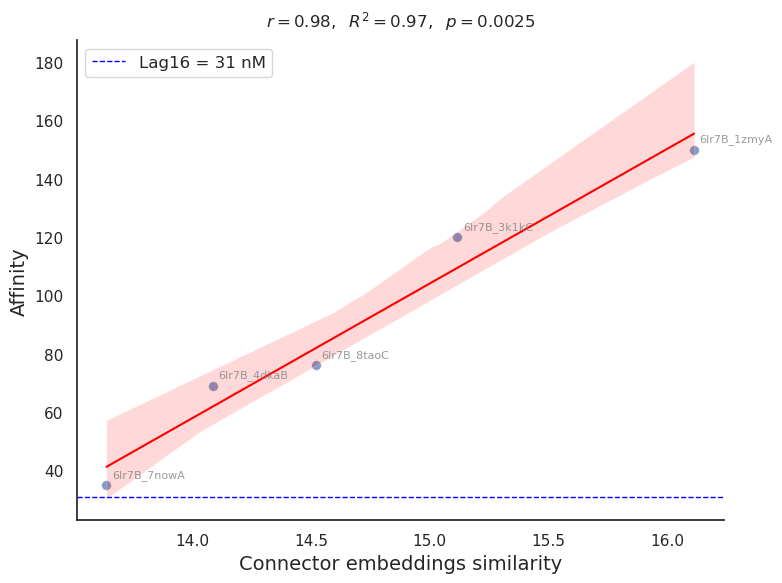

Samples = 500 6lr7B_grafting_connector_candidates_temp07_s500_250901


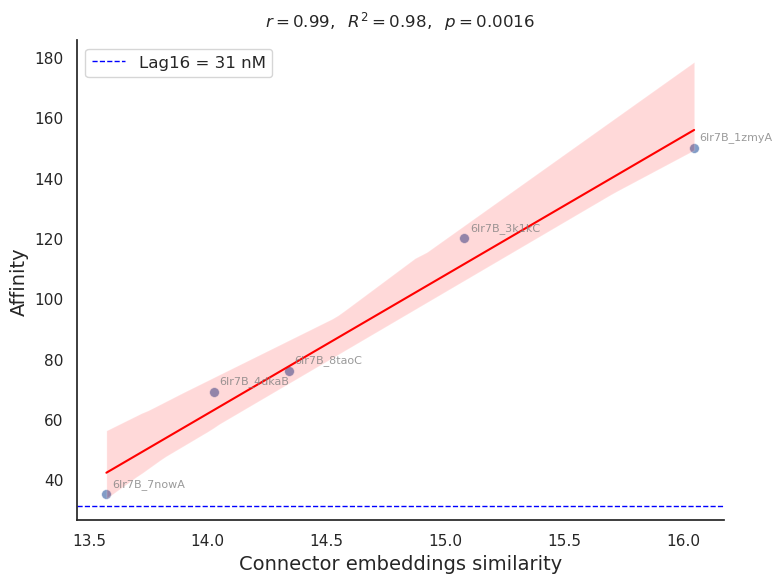

In [8]:
for key, samplename in sample_dict.items():
    print(key, samplename)
    table_path = os.path.join(base_path, samplename)
    affinity_filtered_df = extract_avge_affinity(table_path, selected_stage, selected_id, affinity_df)
    plot_affinity(affinity_filtered_df)

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

def plot_combined_affinity(combined_df, sample_dict, lag16_value=31.0):
    # Selected colors
    sources = list(sample_dict.keys())
    n_sources = len(sources)
    source_colors = sns.color_palette("deep", n_colors=n_sources)
    source_color_map = {src: source_colors[i] for i, src in enumerate(sources)}
    
    # Plot
    sns.set(style="white")
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Line plot
    for src in sources:
        src_data = combined_df[combined_df['source'] == src].copy()
        
        # Sorted by affinity
        src_data = src_data.sort_values('Affinity')
        
        ax.plot(
            src_data['Affinity'],
            src_data['grafted_euclidean_all_raw_embeddings'],
            color=source_color_map[src],
            linewidth=2.5,
            linestyle='-',
            alpha=0.9,
            label=f'{src}'
        )
        
        ax.scatter(
            src_data['Affinity'],
            src_data['grafted_euclidean_all_raw_embeddings'],
            color=source_color_map[src],
            s=80,
            alpha=0.9,
            edgecolor='w',
            linewidth=1.2,
            zorder=5  # Ensure points are above lines
        )
    
    # Draw annotation of pdbs
    unique_pdbs = list(combined_df['PDB_ID'].unique())
    pdb_colors = sns.color_palette("muted", n_colors=max(3, len(unique_pdbs)))
    
    vertical_handles = []
    pdbs_sorted = sorted(unique_pdbs, key=lambda p: float(combined_df.loc[combined_df['PDB_ID']==p, 'Affinity'].iloc[0]))
    
    for i, pdb in enumerate(pdbs_sorted):
        pdb_data = combined_df[combined_df['PDB_ID'] == pdb]
        if pdb_data.empty:
            continue
        affinity_val = float(pdb_data['Affinity'].iloc[0])
        
        color = pdb_colors[i % len(pdb_colors)]
        ax.axvline(x=affinity_val, color=color, linestyle='--', linewidth=1.6, alpha=0.9, zorder=2)
        # For annotation
        vertical_handles.append(Line2D([0], [0], color=color, linestyle='--', linewidth=1.6,
                                       label=f'{pdb}: {affinity_val:.1f} nM'))
    
    # Refference
    ax.axvline(x=lag16_value, color='black', linestyle='--', linewidth=1.6, alpha=0.9, zorder=2)
    lag_handle = Line2D([0], [0], color='black', linestyle='--', linewidth=1.6, label=f'Lag16: {lag16_value} nM')
    vertical_handles_with_lag = vertical_handles + [lag_handle]
    
    ax.set_xlabel('Affinity (nM)', fontsize=16, labelpad=10)
    ax.set_ylabel('Connector embeddings similarity', fontsize=16, labelpad=10)
    
    fig.subplots_adjust(right=0.75)

    source_handles, source_labels = ax.get_legend_handles_labels()
    vertical_labels = [h.get_label() for h in vertical_handles_with_lag]

    # Merged handles and labels
    all_handles = source_handles + vertical_handles_with_lag
    all_labels = source_labels + vertical_labels

    merged_legend = ax.legend(
        handles=all_handles,
        labels=all_labels,
        loc='upper left',
        bbox_to_anchor=(1.02, 1.0), 
        title=None,
        frameon=False, 
        fontsize=16,
        ncol=1 
    )

    merged_legend.get_frame().set_linewidth(0.0)
    merged_legend.get_frame().set_alpha(0.0)
    
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['bottom', 'left']:
        ax.spines[spine].set_linewidth(1.5)
    
    # ax.grid(True, linestyle='--', alpha=0.3, axis='both')
    ax.grid(False)
    
    plt.tight_layout()
    
    return plt


Processing Samples = 5: 6lr7B_grafting_connector_candidates_temp07_s5_250831
Processing Samples = 10: 6lr7B_grafting_connector_candidates_temp07_s10_250901
Processing Samples = 30: 6lr7B_grafting_connector_candidates_temp07_s30_250901
Processing Samples = 50: 6lr7B_grafting_connector_candidates_temp07_s50_250901
Processing Samples = 80: 6lr7B_grafting_connector_candidates_temp07_s80_250901
Processing Samples = 100: 6lr7B_grafting_connector_candidates_temp07_s100_250831
Processing Samples = 500: 6lr7B_grafting_connector_candidates_temp07_s500_250901


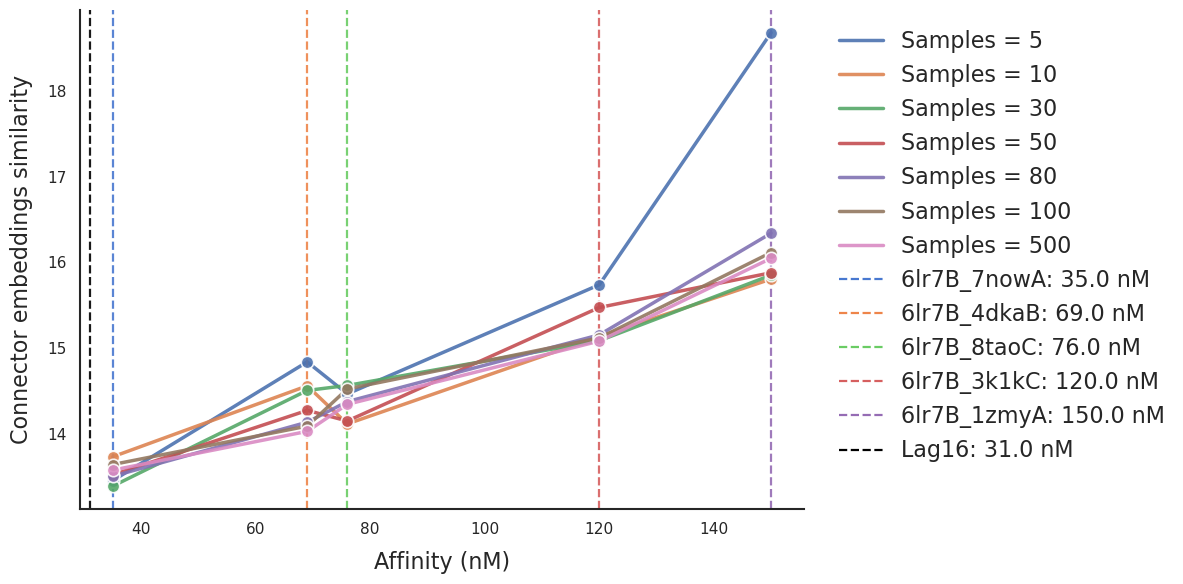

In [100]:
all_data = []
for key, samplename in sample_dict.items():
    print(f"Processing {key}: {samplename}")
    table_path = os.path.join(base_path, samplename)
    df = extract_avge_affinity(table_path, selected_stage, selected_id, affinity_df)
    
    df['source'] = key
    all_data.append(df)
    
combined_df = pd.concat(all_data, ignore_index=True)

if combined_df.empty:
    print("Warning: No data to plot. Check your inputs.")

avge_plt = plot_combined_affinity(combined_df, sample_dict)

avge_plt.savefig(f"{fig_save_path}/affinity_average_score.png", dpi=600, bbox_inches='tight')
avge_plt.show()

# Best

In [14]:
def extract_best_affinity(table_path, selected_stage, selected_id, affinity_df):
    selected_embe = 'raw_embeddings'
    merged_df = None
    for stage in selected_stage:
        table_name = os.path.join(table_path, 'extract_distance/', 'filter_best', f'{stage}_{selected_embe}.tsv')
        df = pd.read_csv(table_name, sep='\t').iloc[:, :2]
        
        if merged_df is None:
            merged_df = df.copy()
        else:
            merged_df = merged_df.merge(df, how='inner', on='PDB_ID')

    filtered_df = merged_df[merged_df['PDB_ID'].isin(selected_id)].copy()

    affinity_filtered_df = affinity_df.merge(filtered_df, how='inner', on='PDB_ID')

    return affinity_filtered_df


Processing Samples = 5: 6lr7B_grafting_connector_candidates_temp07_s5_250831
Processing Samples = 10: 6lr7B_grafting_connector_candidates_temp07_s10_250901
Processing Samples = 30: 6lr7B_grafting_connector_candidates_temp07_s30_250901
Processing Samples = 50: 6lr7B_grafting_connector_candidates_temp07_s50_250901
Processing Samples = 80: 6lr7B_grafting_connector_candidates_temp07_s80_250901
Processing Samples = 100: 6lr7B_grafting_connector_candidates_temp07_s100_250831
Processing Samples = 500: 6lr7B_grafting_connector_candidates_temp07_s500_250901


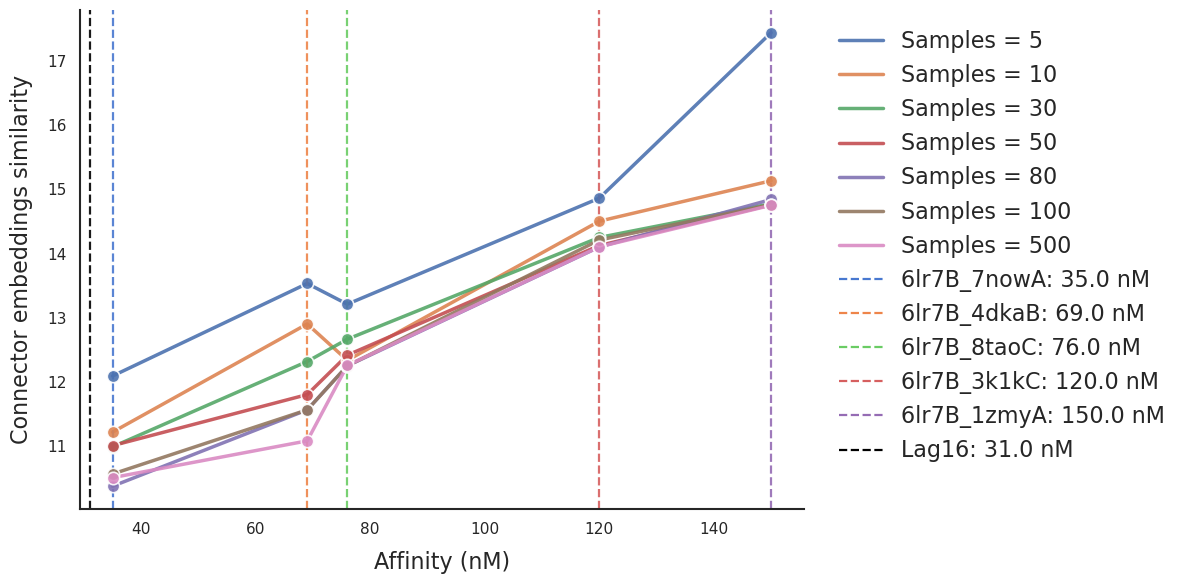

In [101]:
all_data = []
for key, samplename in sample_dict.items():
    print(f"Processing {key}: {samplename}")
    table_path = os.path.join(base_path, samplename)
    df = extract_best_affinity(table_path, selected_stage, selected_id, affinity_df)
    
    df['source'] = key
    all_data.append(df)
    
combined_df = pd.concat(all_data, ignore_index=True)

if combined_df.empty:
    print("Warning: No data to plot. Check your inputs.")

best_plt = plot_combined_affinity(combined_df, sample_dict)

best_plt.savefig(f"{fig_save_path}/affinity_best_score.png", dpi=600, bbox_inches='tight')
best_plt.show()

# cRMSD and pTM

In [47]:
selected_table_path = sample_dict['Samples = 500']

performance_table_name = os.path.join(table_path, 'temp_generation/', 'all_info/', 'all_generation.tsv')
full_distance_table_name = os.path.join(table_path, 'extract_distance/', 'full/', f'grafted_raw_embeddings.tsv')
filt_distance_table_name = os.path.join(table_path, 'extract_distance/', 'filter/', f'grafted_raw_embeddings.tsv')

performance_df = pd.read_csv(performance_table_name, sep='\t')
performance_df.drop(columns=['PDB_ID'], inplace=True)

full_distance_df = pd.read_csv(full_distance_table_name, sep='\t').iloc[:, :3]
full_distance_df.rename(columns={'grafted_euclidean_all_raw_embeddings': 'full_euclidean'}, inplace=True)

filt_distance_df = pd.read_csv(filt_distance_table_name, sep='\t').iloc[:, :3]
filt_distance_df.rename(columns={'grafted_euclidean_all_raw_embeddings': 'filt_euclidean'}, inplace=True)

full_df = performance_df.merge(full_distance_df, how='inner', on='Filename').merge(affinity_df, how='inner', on='PDB_ID')

filt_df = performance_df.merge(filt_distance_df, how='inner', on='Filename').merge(affinity_df, how='inner', on='PDB_ID')
filt_df = filt_df.sort_values(by='filt_euclidean', ascending=True)
selected_df = filt_df.drop_duplicates(subset=['PDB_ID'], keep='first')

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

def plot_performance_affinity(full_df, selected_df, plot_item='cRMSD', lag16_value=31.0):
    # Selected colors (use selected_df里的PDB_ID)
    sources = list(selected_df['PDB_ID'].unique())
    n_sources = len(sources)
    source_colors = sns.color_palette("deep", n_colors=max(n_sources, 1))
    source_color_map = {src: source_colors[i] for i, src in enumerate(sources)}
    
    sns.set(style="white")
    fig, ax = plt.subplots(figsize=(14, 8))

    # Line plot
    ax.plot(
        selected_df['Affinity'],
        selected_df[plot_item],
        color='gray',
        linewidth=2.5,
        linestyle='-',
        alpha=0.9,
        label=None
    )
    
    for src in sources:
        # all data for this source (for scatter background)
        src_full_data = full_df[full_df['PDB_ID'] == src].copy()
        # selected subset (for the connecting line)
        src_sele_data = selected_df[selected_df['PDB_ID'] == src].copy()
        
        # Make sure Affinity is numeric and sort by it before plotting the line
        src_sele_data = src_sele_data.copy()
        src_sele_data['Affinity'] = pd.to_numeric(src_sele_data['Affinity'], errors='coerce')
        src_sele_data = src_sele_data.dropna(subset=['Affinity', plot_item])
        src_sele_data = src_sele_data.sort_values(by='Affinity')
        
        color = source_color_map[src]
        
        # Plot full dataset points (smaller, slightly transparent) so lines are visible above them
        if not src_full_data.empty:
            src_full_data['Affinity'] = pd.to_numeric(src_full_data['Affinity'], errors='coerce')
            src_full_data = src_full_data.dropna(subset=['Affinity', plot_item])
            ax.scatter(
                src_full_data['Affinity'],
                src_full_data[plot_item],
                color=color,
                s=60,
                alpha=0.45,
                edgecolor='w',
                linewidth=0.9,
                zorder=6
            )
        
        # Highlight the selected points as filled markers on top (optional)
        if not src_sele_data.empty:
            ax.scatter(
                src_sele_data['Affinity'],
                src_sele_data[plot_item],
                facecolors=color,
                edgecolors='k',
                s=120,
                linewidth=1.1,
                alpha=1.0,
                zorder=15,
                label=str(src)
            )
    
    # Reference vertical line (lag)
    ax.axvline(x=lag16_value, color='black', linestyle='--', linewidth=1.6, alpha=0.9, zorder=5)
    lag_handle = Line2D([0], [0], color='black', linestyle='--', linewidth=1.6, label=f'Lag16: {lag16_value} nM')
    
    ax.set_xlabel('Affinity (nM)', fontsize=14, labelpad=10)
    ax.set_ylabel(plot_item, fontsize=14, labelpad=10)
    
    fig.subplots_adjust(right=0.75)

    # Build legend: use handles from lines (one per src) + lag handle
    source_handles, source_labels = ax.get_legend_handles_labels()
    all_handles = source_handles + [lag_handle]
    all_labels = source_labels + [lag_handle.get_label()]

    merged_legend = ax.legend(
        handles=all_handles,
        labels=all_labels,
        loc='upper left',
        bbox_to_anchor=(1.02, 1.0),
        frameon=False,
        fontsize=12,
        ncol=1
    )

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['bottom', 'left']:
        ax.spines[spine].set_linewidth(1.5)
    
    ax.grid(False)
    plt.tight_layout()
    return plt


In [110]:
def plot_performance(full_df, selected_df):
    # Selected colors (use selected_df里的PDB_ID)
    sources = list(selected_df['PDB_ID'].unique())
    n_sources = len(sources)
    source_colors = sns.color_palette("deep", n_colors=max(n_sources, 1))
    source_color_map = {src: source_colors[i] for i, src in enumerate(sources)}
    
    sns.set(style="white")
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for src in sources:
        # all data for this source (for scatter background)
        src_full_data = full_df[full_df['PDB_ID'] == src].copy()
        # selected subset (for the connecting line)
        src_sele_data = selected_df[selected_df['PDB_ID'] == src].copy()
        color = source_color_map[src]
        
        # Plot full dataset points (smaller, slightly transparent) so lines are visible above them
        if not src_full_data.empty:
            src_full_data['Affinity'] = pd.to_numeric(src_full_data['Affinity'], errors='coerce')
            ax.scatter(
                src_full_data['cRMSD'],
                src_full_data['pTM'],
                color=color,
                s=60,
                alpha=0.45,
                edgecolor='w',
                linewidth=0.9,
                zorder=6
            )
        
        # Highlight the selected points as filled markers on top (optional)
        if not src_sele_data.empty:
            ax.scatter(
                src_sele_data['cRMSD'],
                src_sele_data['pTM'],
                facecolors=color,
                edgecolors='k',
                s=120,
                linewidth=1.1,
                alpha=1.0,
                zorder=15,
                label=str(src)
            )
    
    ax.set_xlabel('cRMSD', fontsize=14, labelpad=10)
    ax.set_ylabel('pTM', fontsize=14, labelpad=10)
    
    fig.subplots_adjust(right=0.75)

    ax.legend(
        loc='upper left',
        bbox_to_anchor=(1.02, 1.0),
        frameon=False,
        fontsize=14,
        ncol=1
    )

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['bottom', 'left']:
        ax.spines[spine].set_linewidth(1.5)
    
    ax.grid(False)
    plt.tight_layout()
    return plt


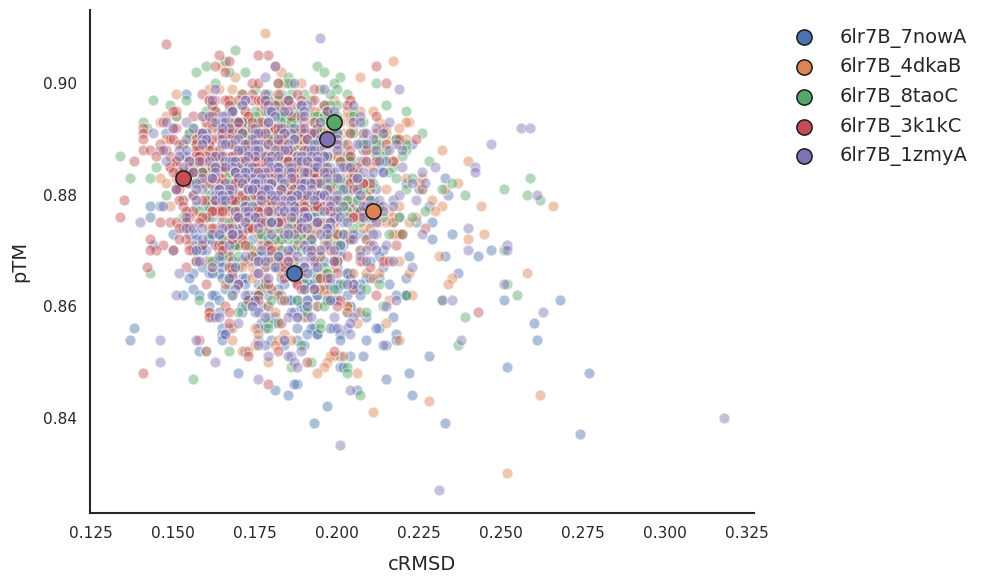

In [111]:
performance_plt = plot_performance(full_df, selected_df)

performance_plt.savefig(f"{fig_save_path}/grafting_performance.png", dpi=600, bbox_inches='tight')
performance_plt.show()

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_performance_dualbar(full_df):

    df = full_df.copy()
    df['Affinity'] = pd.to_numeric(df['Affinity'], errors='coerce')

    affinity_median = df.groupby('PDB_ID')['Affinity'].median().dropna()

    all_pdbs = list(df['PDB_ID'].unique())

    sorted_with_aff = affinity_median.sort_values().index.tolist()
    remaining = [p for p in all_pdbs if p not in sorted_with_aff]
    pdb_list = sorted_with_aff + remaining

    sns.set(style="white")
    fig, ax = plt.subplots(figsize=(max(10, len(pdb_list)*1.2), 6))
    ax2 = ax.twinx()

    x = np.arange(len(pdb_list))
    bar_width = 0.35
    left_positions  = x - bar_width/2
    right_positions = x + bar_width/2

    cRMSD_groups = [df.loc[df['PDB_ID'] == pdb, 'cRMSD'].dropna().astype(float).values
                    for pdb in pdb_list]
    pTM_groups   = [df.loc[df['PDB_ID'] == pdb, 'pTM'].dropna().astype(float).values
                    for pdb in pdb_list]

    colors = sns.color_palette("deep", n_colors=len(pdb_list))

    bp1 = ax.boxplot(
        cRMSD_groups,
        positions=left_positions,
        widths=bar_width,
        patch_artist=True,
        manage_ticks=False
    )
    for i, box in enumerate(bp1['boxes']):
        box.set(facecolor=colors[i], edgecolor='black', linewidth=0.8)
    for item in bp1.get('whiskers', []):
        item.set(color='black', linewidth=0.8)
    for item in bp1.get('caps', []):
        item.set(color='black', linewidth=0.8)
    for item in bp1.get('medians', []):
        item.set(color='white', linewidth=1.5)
    for item in bp1.get('fliers', []):
        item.set(marker='o', markerfacecolor='none', markeredgecolor='gray', markersize=4)

    bp2 = ax2.boxplot(
        pTM_groups,
        positions=right_positions,
        widths=bar_width,
        patch_artist=True,
        manage_ticks=False
    )
    for i, box in enumerate(bp2['boxes']):
        rgba = tuple(colors[i]) + (0.6,)
        box.set(facecolor=rgba, edgecolor='black', linewidth=0.8)
    for item in bp2.get('whiskers', []):
        item.set(color='black', linewidth=0.8)
    for item in bp2.get('caps', []):
        item.set(color='black', linewidth=0.8)
    for item in bp2.get('medians', []):
        item.set(color='black', linewidth=1.2)
    for item in bp2.get('fliers', []):
        item.set(marker='o', markerfacecolor='none', markeredgecolor='gray', markersize=4)

    ax.set_xticks(x)
    ax.set_xticklabels(pdb_list, rotation=0, ha='center', fontsize=13)

    # ax.set_xlabel('PDB_ID', fontsize=13)
    ax.set_ylabel('cRMSD', fontsize=13)
    ax2.set_ylabel('pTM', fontsize=13)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.spines['left'].set_linewidth(1.2)

    ax.grid(axis='y', linestyle='--', alpha=0.25)
    ax2.grid(False)

    plt.tight_layout()
    return plt


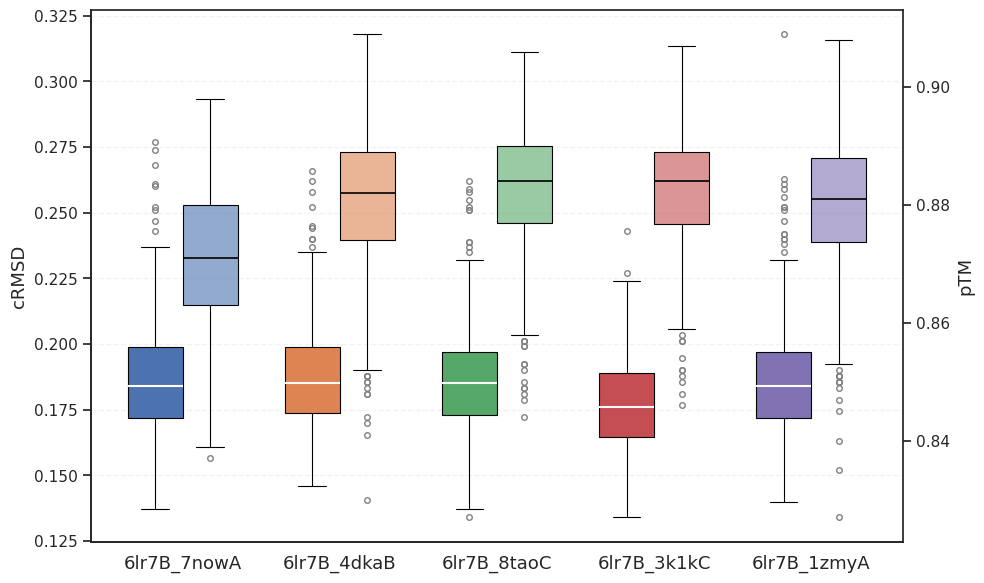

In [105]:
performance_plt = plot_performance_dualbar(full_df)

performance_plt.savefig(f"{fig_save_path}/grafting_performance_boxplot.png", dpi=600, bbox_inches='tight')
performance_plt.show()